In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "10"

from queue import PriorityQueue

from variable_print import p,ps,pst
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## VanillaMCAgent   

Vanilla MC policy evaluation : $$ V(s) \leftarrow \frac{G(s)}{N(s)}$$
>$G(s)$: 상태 $s$의 리턴 추산치의 합  
>$N(s)$: 상태 $s$의 방문 횟수  
>policy update :행동 가치함수 $Q(s,a)$에 대한 '$\epsilon$-탐욕적 정책' 적용  

**클래스의 컨스트럭터의 인자**  
1. `gamma` : 감가율
2. `num_states` : 상태공간의 크기(상태의 수)
3. `num_actions` : 행동공간의 크기 (행동의 수)
4. `epsilon`: $\epsilon$-탐욕적 정책 비적용 확률(1=100%:random action)  

In [4]:
class VanillaMCAgent:
    """
    V(s) <- s(s) / n(s)  : s(s)=sum(Gt(s))
    Q(s,a) <- s(s,a) / n(s,a)
    """
    def __init__(self,
                 gamma: float,
                 num_states: int,
                 num_actions: int,
                 epsilon: float):
        self.gamma = gamma
        self.num_states = num_states
        self.num_actions = num_actions
        self.epsilon = epsilon

        self._eps = 1e-10  # for stable computation of V and Q. NOT the one for e-greedy !

        # Initialize statistics
        self.s_v = None # s(s)
        self.n_v = None # n(s)
        self.s_q = None # s(s,a)
        self.n_q = None # n(s,a)

        self.reset_statistics()
        # Initialize state value function V and action value function Q
        self.v = None
        self.q = None
        self.reset_values()

        # Initialize "policy Q"
        # "policy Q" is the one used for policy generation.
        self._policy_q = None
        self.reset_policy()

    def reset_statistics(self):
        self.s_v = np.zeros(shape=self.num_states) # sum_v(Gt(s))
        self.n_v = np.zeros(shape=self.num_states) # n_v(s)
        self.s_q = np.zeros(shape=(self.num_states, self.num_actions)) #sum_q(s,a))
        self.n_q = np.zeros(shape=(self.num_states, self.num_actions)) #n_q(s,a)

    def reset_values(self):
        self.v = np.zeros(shape=self.num_states) #v(s,)
        self.q = np.zeros(shape=(self.num_states, self.num_actions)) #q(s,a)

    def reset_policy(self):
        self._policy_q = np.zeros(shape=(self.num_states, self.num_actions))

    def reset(self):
        self.reset_statistics()
        self.reset_values()
        self.reset_policy()

    def update(self, episode):
        states, actions, rewards = episode

        # reversing the inputs!
        # for efficient computation of returns
        states = reversed(states)
        actions = reversed(actions)
        rewards = reversed(rewards)

        iter = zip(states, actions, rewards)
        cum_r = 0
        for s, a, r in iter: # Every-visit MC policy evaluation
            cum_r *= self.gamma
            cum_r += r

            self.n_v[s] += 1
            self.n_q[s, a] += 1

            self.s_v[s] += cum_r
            self.s_q[s, a] += cum_r
        self.compute_values()

    def compute_values(self):
        self.v = self.s_v / (self.n_v + self._eps)
        self.q = self.s_q / (self.n_q + self._eps)

    def get_action(self, state):
        prob = np.random.uniform(0.0, 1.0, 1)
        # e-greedy policy over Q
        if prob <= self.epsilon:  # random action(policy) 비율
            action = np.random.choice(range(self.num_actions))
        else:  # greedy policy
            action = self._policy_q[state, :].argmax()
        return action

    def improve_policy(self):
        self._policy_q = self.q.copy()
        self.reset_statistics()

    def decaying_epsilon(self, factor):
        self.epsilon *= factor


In [5]:
nx, ny = 4, 4

mc_agent = VanillaMCAgent(gamma=1.0,
                        num_states=nx * ny,
                        num_actions=4,
                        epsilon=1.0) # 1.0:모든 행동을 random으로 적용(greedy X)

In [6]:
action_mapper = { 0: 'UP',
                  1: 'RIGHT',
                  2: 'DOWN',
                  3: 'LEFT' }

## [Env <--> Agent] interaction


### `GridworldEnv`생성

In [7]:
from gridworld import GridworldEnv

#nx, ny = 4, 4
env = GridworldEnv([ny, nx])

/usr/local/lib/python3.11/dist-packages/gym/utils/seeding.py:41: DeprecationWarning: WARN: Function `rng.rand(*size)` is marked as deprecated and will be removed in the future. Please use `Generator.random(size)` instead.
  deprecation(


* get_action( ) method 구현

```python  
def get_action(self, state):
    prob = np.random.uniform(0.0, 1.0, 1)
    # e-greedy policy over Q
    if prob <= self.epsilon:  # random action(policy) 비율
        action = np.random.choice(range(self.num_actions))
    else:  # greedy policy
        action = self._policy_q[state, :].argmax()
    return action
```

### Interaction  
#### 현재는 random policy 적용

In [8]:
env.reset()
step_counter = 0
while True:
    print(f"At t = {step_counter}")
    env.render()
    ##
    cur_state = env.observe()
    action = mc_agent.get_action(cur_state) # agent로 부터 action 받음
    next_state, reward, done, info = env.step(action)
    ##
    print(f"state : {cur_state}\t aciton : {action_mapper[action]}")
    print(f"reward : {reward}\t next state : {next_state}\n")
    step_counter += 1
    if done: break

At t = 0
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T
state : 2	 aciton : RIGHT
reward : -1.0	 next state : 3

At t = 1
T  o  o  x
o  o  o  o
o  o  o  o
o  o  o  T
state : 3	 aciton : LEFT
reward : -1.0	 next state : 2

At t = 2
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T
state : 2	 aciton : RIGHT
reward : -1.0	 next state : 3

At t = 3
T  o  o  x
o  o  o  o
o  o  o  o
o  o  o  T
state : 3	 aciton : DOWN
reward : -1.0	 next state : 7

At t = 4
T  o  o  o
o  o  o  x
o  o  o  o
o  o  o  T
state : 7	 aciton : DOWN
reward : -1.0	 next state : 11

At t = 5
T  o  o  o
o  o  o  o
o  o  o  x
o  o  o  T
state : 11	 aciton : UP
reward : -1.0	 next state : 7

At t = 6
T  o  o  o
o  o  o  x
o  o  o  o
o  o  o  T
state : 7	 aciton : DOWN
reward : -1.0	 next state : 11

At t = 7
T  o  o  o
o  o  o  o
o  o  o  x
o  o  o  T
state : 11	 aciton : DOWN
reward : -1.0	 next state : 15



## Vanilla Monte-calro Policy evaluation


### Episode 수행 : run_eposide() methode / Main loop

**episode한번 종료되면 update한번**

In [9]:
def run_episode(env, agent, timeout=200):
    env.reset()   # s <- random state
    states = []   # trajectory 보관
    actions = []
    rewards = []

    i = 0
    timeouted = False
    while True:    # Terminal 나올때 까지
        state = env.s
        action = agent.get_action(state)
        next_state, reward, done, info = env.step(action)
        # trajectory 저장
        states.append(state)
        actions.append(action)
        rewards.append(reward)

        if done: break
        i += 1
        if i > timeout:
            timeouted = True
            break

    if not timeouted: # agent update
        episode = (states, actions, rewards)
        agent.update(episode)  # every-visit Monte-carlo evaluation

* episode 반복해서 V(s), Q(s,a) update 시행

In [10]:
%%time
mc_agent.reset_statistics() # v(s,),n_v(s,) q(s,a), n_q(s,a) <- 0
for _ in range(10):
    run_episode(env, mc_agent)

CPU times: user 11.5 ms, sys: 0 ns, total: 11.5 ms
Wall time: 12.1 ms


### `agent.update(episode)` methode: every-visit Monte-carlo evaluation  



### agent.compute_values()
agent.update(episode)에서 계산된 정보로 상태 가치함수 $V$ 와 행동 가치함수 $Q$ 를 계산  



```python
def compute_values(self):
    self.v = self.s_v / (self.n_v + self._eps)
    self.q = self.s_q / (self.n_q + self._eps)
```

In [11]:
mc_agent.v #v(s)

array([  0.        , -18.        , -30.92857143, -20.36      ,
        -3.66666667, -17.85714286, -22.85714286, -15.        ,
        -9.77777778, -18.08333333, -19.        , -17.33333333,
       -34.8       , -26.77777778, -13.33333333,   0.        ])

In [12]:
mc_agent.q #q(s,a)

array([[  0.        ,   0.        ,   0.        ,   0.        ],
       [-25.        , -20.        , -24.        ,  -1.        ],
       [-36.83333333, -34.5       , -37.        , -10.66666667],
       [-16.1       , -21.16666667, -16.83333333, -40.        ],
       [ -1.        ,  -4.        , -10.        ,  -3.66666667],
       [-38.        , -22.4       , -22.66666667,  -6.4       ],
       [-22.        , -25.33333333, -22.66666667, -22.        ],
       [-21.16666667,  -9.16666667, -11.33333333, -18.        ],
       [ -4.66666667,  -4.        , -25.        ,  -6.66666667],
       [-20.33333333, -14.66666667,   0.        , -17.        ],
       [-19.        , -29.        ,  -2.        , -20.75      ],
       [-18.66666667, -23.5       ,  -1.        ,   0.        ],
       [  0.        , -30.2       , -32.375     , -40.85714286],
       [-22.        , -20.        , -31.        , -36.5       ],
       [-13.        ,  -1.        , -28.        , -18.5       ],
       [  0.        ,   0

### Vanilla Monte-carlo evaluation 결과(10번 episode진행)    
#### **`DP_agent`와 비교해 보자**  

In [13]:
from tensorized_dp import TensorDP

dp_agent = TensorDP()
dp_agent.set_env(env)

Environment : #state = 16 , #actions = 4 


In [14]:
%%time
# Random policy에 대한 evaluation 결과 얻어 오기
v_pi = dp_agent.policy_evaluation()

CPU times: user 3.81 ms, sys: 0 ns, total: 3.81 ms
Wall time: 3.98 ms


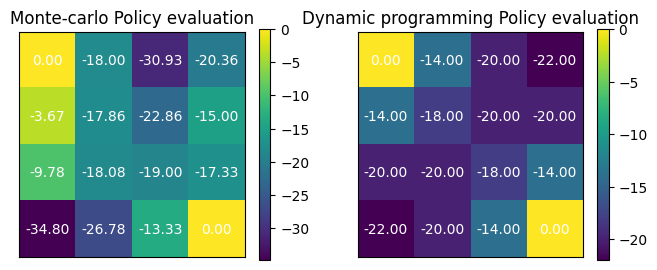

In [15]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
visualize_value_function(ax[0], mc_agent.v, nx, ny)
_ = ax[0].set_title("Monte-carlo Policy evaluation")

visualize_value_function(ax[1], v_pi, nx, ny)
_ = ax[1].set_title("Dynamic programming Policy evaluation")

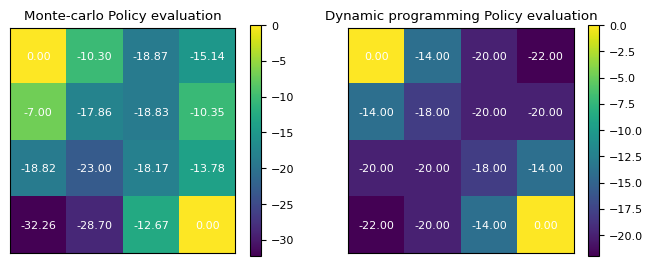

###Episode를 늘려서 결과를 확인하자  
>`dp_agent` 와 `mc_agent`의 결과를 비교하자   
> `dp_agent`는 정답  

In [16]:
## total_eps 시행, log_every간견으로 log 저장
def run_episodes(env, agent, total_eps, log_every):
    mc_values = []
    log_iters = []
    agent.reset_statistics() # v(s,),n_v(s,) q(s,a), n_q(s,a) <- 0
    for i in range(total_eps+1):
        run_episode(env, agent)
        if i % log_every == 0:
            mc_values.append(agent.v.copy())
            log_iters.append(i)
    info = dict()
    info['values'] = mc_values
    info['iters'] = log_iters
    return info

In [17]:
%%time
total_eps = 2000
log_every = 500
## [0, 500, 1000, 1500, 2000]에서 log 저장
info = run_episodes(env, mc_agent, total_eps, log_every)

CPU times: user 1.89 s, sys: 48.7 ms, total: 1.93 s
Wall time: 1.96 s


In [19]:
log_iters = info['iters']
mc_values = info['values']

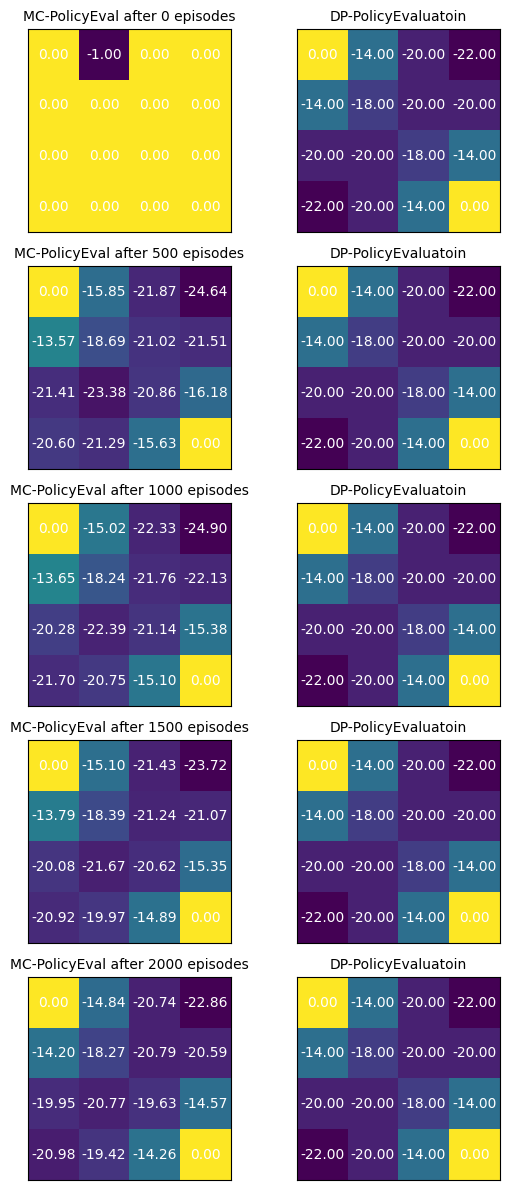

In [20]:
n_rows = len(log_iters)
figsize_multiplier = 4

fig, ax = plt.subplots(n_rows, 2, figsize=(n_rows*figsize_multiplier*0.3,
                                           3*figsize_multiplier))

for viz_i, i in enumerate(log_iters):
    visualize_value_function(ax[viz_i, 0], mc_values[viz_i], nx, ny,
                            plot_cbar=False)
    _ = ax[viz_i, 0].set_title(f"MC-PolicyEval after {i} episodes", size=10)

    visualize_value_function(ax[viz_i, 1], v_pi, nx, ny,
                             plot_cbar=False)
    _ = ax[viz_i, 1].set_title("DP-PolicyEvaluatoin", size=10)

fig.tight_layout()

###  Monte-carlo Policy evaluation 결과의 분산 확인해 보기  
>10번을 시행하여 episode 진행에 따른 error의 평균, 분산 변화를 확인

In [21]:
%%time
reps = 10
values_over_runs = []
total_eps = 3000
log_every = 30

for i in range(reps): # 3000 epi x 10 reps
    print(f"start to run {i}th experiment ... ")
    info = run_episodes(env, mc_agent, total_eps, log_every)
    values_over_runs.append(info['values']) #(logs,v(s,))

values_over_runs = np.stack(values_over_runs) #(reps,logs,s):(10,101,16)

start to run 0th experiment ... 
start to run 1th experiment ... 
start to run 2th experiment ... 
start to run 3th experiment ... 
start to run 4th experiment ... 
start to run 5th experiment ... 
start to run 6th experiment ... 
start to run 7th experiment ... 
start to run 8th experiment ... 
start to run 9th experiment ... 
CPU times: user 22.6 s, sys: 90.3 ms, total: 22.7 s
Wall time: 23.3 s


Wall time: 15.9 s



In [22]:
ps(values_over_runs) #(reps,logs,v(s,)):(10,101,16)

<<>> Shape(10, 101, 16)


In [23]:
## v_pi = dp_agent.policy_evaluation() #dp로 얻은 정답
v_pi_expanded = np.expand_dims(v_pi, axis=(0,1)) #(1,1,16)
ps(v_pi_expanded)

<<>> Shape(1, 1, 16)


In [24]:
errors = np.linalg.norm(values_over_runs - v_pi_expanded, axis=-1)
error_mean = np.mean(errors, axis=0)
error_std = np.std(errors, axis=0)

g_drive = path + "datasets/DRL/"; os.makedirs(g_drive, exist_ok=True)
np.save(g_drive+'mc_errors.npy', errors)

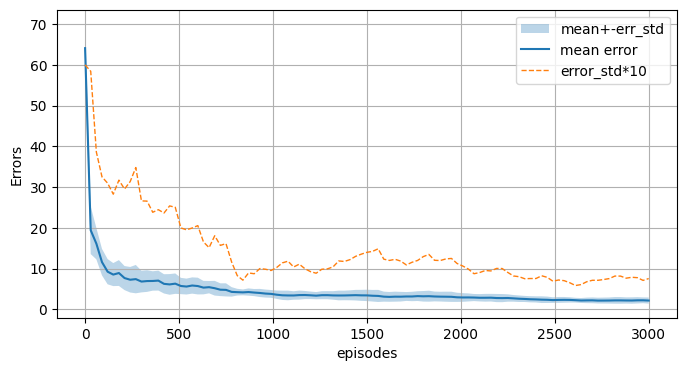

In [25]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.grid()
ax.fill_between(x=info['iters'],
                y1=error_mean + error_std,
                y2=error_mean - error_std,
                label='mean+-err_std',
                alpha=0.3)
ax.plot(info['iters'], error_mean, '-', label='mean error')
ax.plot(info['iters'], error_std*10,'--', label="error_std*10",linewidth=1)

ax.legend()
_ = ax.set_xlabel('episodes')
_ = ax.set_ylabel('Errors')

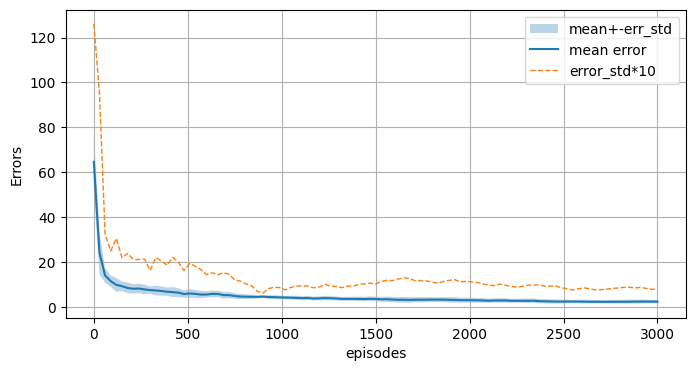

## MCAgent: Incremental MC Policy Evlauation  
Vanilla MC policy evaluation : $$ V(s) \leftarrow \frac{G(s)}{N(s)}$$  
Incremental MC policy evaluation :   
$$V(s) \leftarrow V(s) + \alpha (G_t - V(s))$$  
`MCAgent`: $\alpha=lr$   

In [26]:
## VanillaMCAgent 상속 받아서 updata만 수정 ##
class MCAgent(VanillaMCAgent):
    """
    lr 적용
    V(s) <- V(s) + lr * (Gt - V(s))
    Q(s,a) <- Q(s,a) + lr * (Gt - Q(s,a))
    """
    def __init__(self,
                 gamma: float,
                 num_states: int,
                 num_actions: int,
                 epsilon: float,
                 lr: float):
        super(MCAgent, self).__init__(gamma=gamma,
                                      num_states=num_states,
                                      num_actions=num_actions,
                                      epsilon=epsilon)
        self.lr = lr

    def update(self, episode):
        states, actions, rewards = episode

        states = reversed(states) # reversing the inputs!
        actions = reversed(actions)
        rewards = reversed(rewards)

        iter = zip(states, actions, rewards)
        cum_r = 0
        for s, a, r in iter: # epi.에 있는 v,q update
            cum_r *= self.gamma
            cum_r += r
            # v(s)<- V(s) + alpha * (Gt - v(s))
            self.v[s] += self.lr * (cum_r - self.v[s])
            # q(s,a)<- alpha * (Gt - q(s,a))
            self.q[s, a] += self.lr * (cum_r - self.q[s, a])

In [27]:
inc_mc_agent = MCAgent(gamma=1.0,
                       lr=1e-3,
                       num_states=nx * ny,
                       num_actions=4,
                       epsilon=1.0)

In [28]:
%%time
for _ in range(2000):
    run_episode(env, inc_mc_agent)

CPU times: user 1.35 s, sys: 4.79 ms, total: 1.35 s
Wall time: 1.35 s


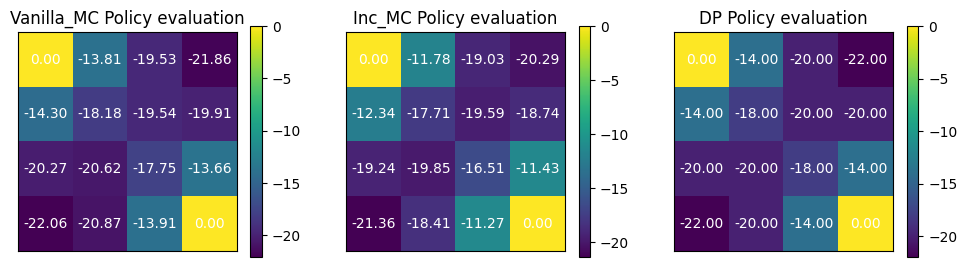

In [29]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
visualize_value_function(ax[0], mc_agent.v, nx, ny)
_ = ax[0].set_title("Vanilla_MC Policy evaluation")

visualize_value_function(ax[1], inc_mc_agent.v, nx, ny)
_ = ax[1].set_title("Inc_MC Policy evaluation")

visualize_value_function(ax[2], v_pi, nx, ny)
_ = ax[2].set_title("DP Policy evaluation")

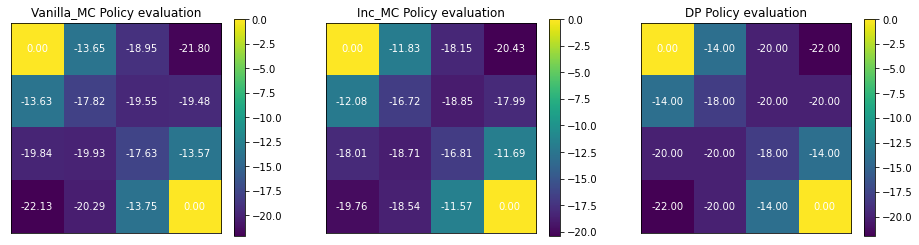

### Increment MCAgent, Learning rate 변화에 따른 학습 비교  


In [30]:
def run_mc_agent_with_lr(agent, env):
    lr_list = [1.0,0.01,0.001]
    mc_v = []
    for i in range(len(lr_list)):
        agent.reset()
        agent.lr = lr_list[i]
        for _ in range(2000):
            run_episode(env, agent)
        mc_v.append(agent.v)

    fig, ax = plt.subplots(1,3, figsize=(12,3))
    visualize_value_function(ax[0], mc_v[0], nx, ny)
    _ = ax[0].set_title(f"Inc. MC(lr={lr_list[0]})")
    visualize_value_function(ax[1], mc_v[1], nx, ny)
    _ = ax[1].set_title(f"Inc. MC(lr={lr_list[1]})")
    visualize_value_function(ax[2], mc_v[2], nx, ny)
    _ = ax[2].set_title(f"Inc. MC(lr={lr_list[2]})")

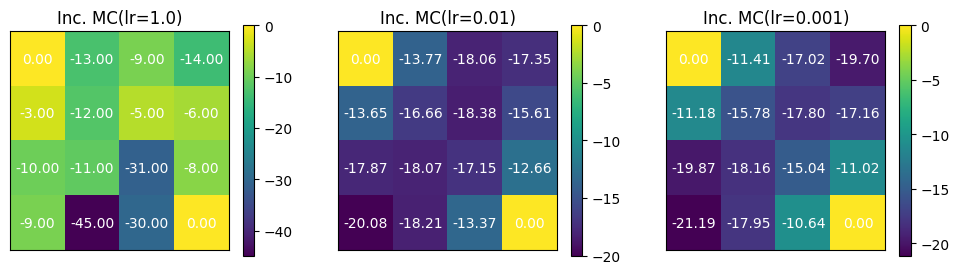

In [31]:
run_mc_agent_with_lr(inc_mc_agent,env)

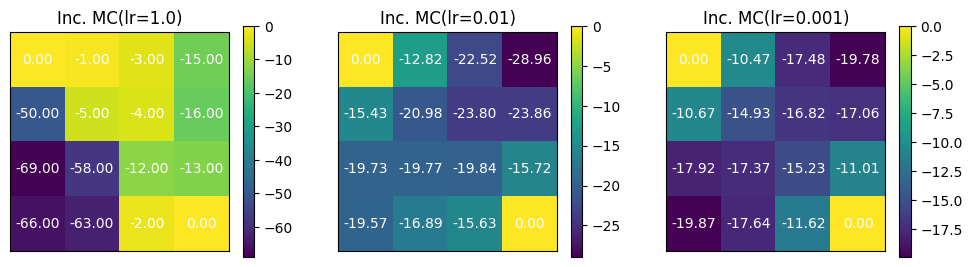